# Arithmetic Square-Wave Sweep — Extended Analysis

Deeper analysis of the GPU power-management loop response to arithmetic square-wave stimuli.
Builds on the basic pipeline from `arithmetic-square-wave-clean.ipynb` and adds:

| Section | What it shows |
|---------|---------------|
| 4 · Per-device comparison | Device-to-device power variance; cross-device correlation |
| 5 · Transfer function & −3 dB bandwidth | Formal loop bandwidth from harmonic transmission ratios |
| 6 · Control-loop model fitting | First-order LP fit; corner frequency fc and time constant τ |
| 7 · Cycle-folded waveforms + ridgeline | Average cycle shape; stacked ridge view across the sweep |
| 8 · Rise / fall time | 10–90 % slew rates extracted from folded profiles |
| 9 · Thermal baseline drift | Cold-phase floor power — does idle heat accumulate at high f? |
| 10 · Power distributions | Violin plots of the power PDF at each sweep point |
| 11 · Energy per cycle | Joules per hot/cold period; efficiency vs ideal |
| 13 · Multi-harmonic Bode plot | Transfer function using all odd harmonics, not just f₀ |
| 14 · Rise / fall asymmetry | Heating vs cooling slew rate ratio across the sweep |
| 15 · Phase-sweep heatmap | 2-D view of folded waveform shape vs drive frequency |
| 16 · Metric correlation matrix | Pearson correlations between all key scalars |
| 17 · Summary dashboard | Six key scalars on one page |

**Inputs:** `rocm_smi::energy_count:device=*` only — no clock or throttle telemetry.

## 1 · Setup

In [1]:
import os
import re
from glob import glob

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
from matplotlib.ticker import AutoMinorLocator
from scipy import signal, optimize, stats
from scipy.stats import binned_statistic
from scipy.optimize import minimize_scalar, curve_fit

from ampere import (
    Ensemble, Metric, MetricConfig, MetricType,
    connect, set_backend, ak,
)

set_backend('pandas')
connect(server="localhost", port=5555)

plt.rcParams.update({
    'figure.dpi':         110,
    'savefig.dpi':        140,
    'axes.spines.top':    False,
    'axes.spines.right':  False,
    'axes.titleweight':   'bold',
    'axes.titlepad':      10,
    'axes.labelsize':     11,
    'axes.titlesize':     12,
    'axes.grid':          True,
    'grid.alpha':         0.22,
    'grid.linestyle':     '--',
    'grid.linewidth':     0.7,
    'font.size':          11,
    'legend.frameon':     False,
    'legend.fontsize':    9,
})

TDP         = 560          # W, MI300A nominal per device
GPU_DEVICES = (0, 2, 4, 6)
TDP_TOTAL   = TDP * len(GPU_DEVICES)

    _         _                   _       
   / \   _ __| | _____  _   _  __| | __ _ 
  / _ \ | '__| |/ / _ \| | | |/ _` |/ _` |
 / ___ \| |  |   < (_) | |_| | (_| | (_| |
/_/   \_\_|  |_|\_\___/ \__,_|\__,_|\__,_|
                                          

Client Version: v2025.07.03+64.gd6838bfbe
Pandas backend active — skipping Arkouda connection.


## 2 · Load traces and derive power metrics

Same pipeline as the clean notebook:
```
energy_count[J] ─d/dt→ inst_power[W] ─sum devices→ combined_gpu_power[W]
```

In [2]:
TRACE_ROOT = "/Users/adam/Documents/python/ampere/examples/arithmetic-square-wave-04-29-26-13:50:09"
TRACES = sorted(
    glob(os.path.join(TRACE_ROOT, "cycles-*")),
    key=lambda s: int(s.rsplit('-', 1)[-1]),
)

for trace in TRACES:
    if not glob(os.path.join(trace, "*.csv")):
        os.system(f"cd {trace} && ~/otf2csv ./traces.otf2")

configs = {
    re.compile(r".*rocm.*energy.*"): MetricConfig(MetricType.CUMULATIVE, scale_factor=1e-6),
}
ensemble = Ensemble.from_trace_paths(TRACES, {"Node0": ["Process"]}, configs)

cycle_counts = [int(t.rsplit('-', 1)[-1]) for t in TRACES]
N_RUNS = len(cycle_counts)
print(f"Loaded {N_RUNS} runs:  cycles ∈ [{min(cycle_counts)}, {max(cycle_counts)}]")

Loading Runs: 100%|██████████| 32/32 [00:00<00:00, 53.60it/s]

Loaded 32 runs:  cycles ∈ [1, 5040]


In [3]:
def differentiate_energy(energy_metric):
    t, e = energy_metric.times, energy_metric.values
    dt = t[1:] - t[:-1]
    de = e[1:] - e[:-1]
    p  = de / dt
    p  = ak.where((p < 0) | (dt <= 0), 0.0, p)
    return Metric("power", t[1:], p, MetricConfig(MetricType.INSTANTANEOUS))


def sum_power(*metrics):
    L     = min(len(m.times) for m in metrics)
    times = min((m.times for m in metrics), key=len)
    values = np.sum([np.asarray(m.values)[:L] for m in metrics], axis=0)
    return Metric('combined_gpu_power', times, values,
                  MetricConfig(MetricType.INSTANTANEOUS))


for d in GPU_DEVICES:
    ensemble.add_derived_metric(
        f"A2rocm_smi:::inst_power:device={d}",
        differentiate_energy,
        f"A2rocm_smi:::energy_count:device={d}",
    )

ensemble.add_derived_metric(
    "A2rocm_smi:::combined_gpu_power",
    sum_power,
    *(f"A2rocm_smi:::inst_power:device={d}" for d in GPU_DEVICES),
)

Deriving metric 'A2rocm_smi:::inst_power:device=0'...
Deriving metric 'A2rocm_smi:::inst_power:device=2'...
Deriving metric 'A2rocm_smi:::inst_power:device=4'...
Deriving metric 'A2rocm_smi:::inst_power:device=6'...
Deriving metric 'A2rocm_smi:::combined_gpu_power'...


## 3 · Per-run cache

In [4]:
PALETTE = plt.cm.plasma(np.linspace(0.12, 0.88, N_RUNS))


def extract(metric):
    return np.asarray(metric.times), np.asarray(metric.values)


combined_power = []
device_power   = {d: [] for d in GPU_DEVICES}

for run in ensemble.runs:
    combined_power.append(extract(run.nodes[0].metrics["A2rocm_smi:::combined_gpu_power"]))
    for d in GPU_DEVICES:
        device_power[d].append(extract(run.nodes[0].metrics[f"A2rocm_smi:::inst_power:device={d}"]))


def f0_of(i):
    t, _ = combined_power[i]
    return cycle_counts[i] / (t[-1] - t[0])


def half_period_ms_of(i):
    t, _ = combined_power[i]
    return 1000.0 * (t[-1] - t[0]) / (2 * cycle_counts[i])

## 4 · Per-device comparison

How consistent are the four GPU devices? We check both a representative
time-domain trace and the cross-device Pearson correlation matrix for
every run in the sweep.

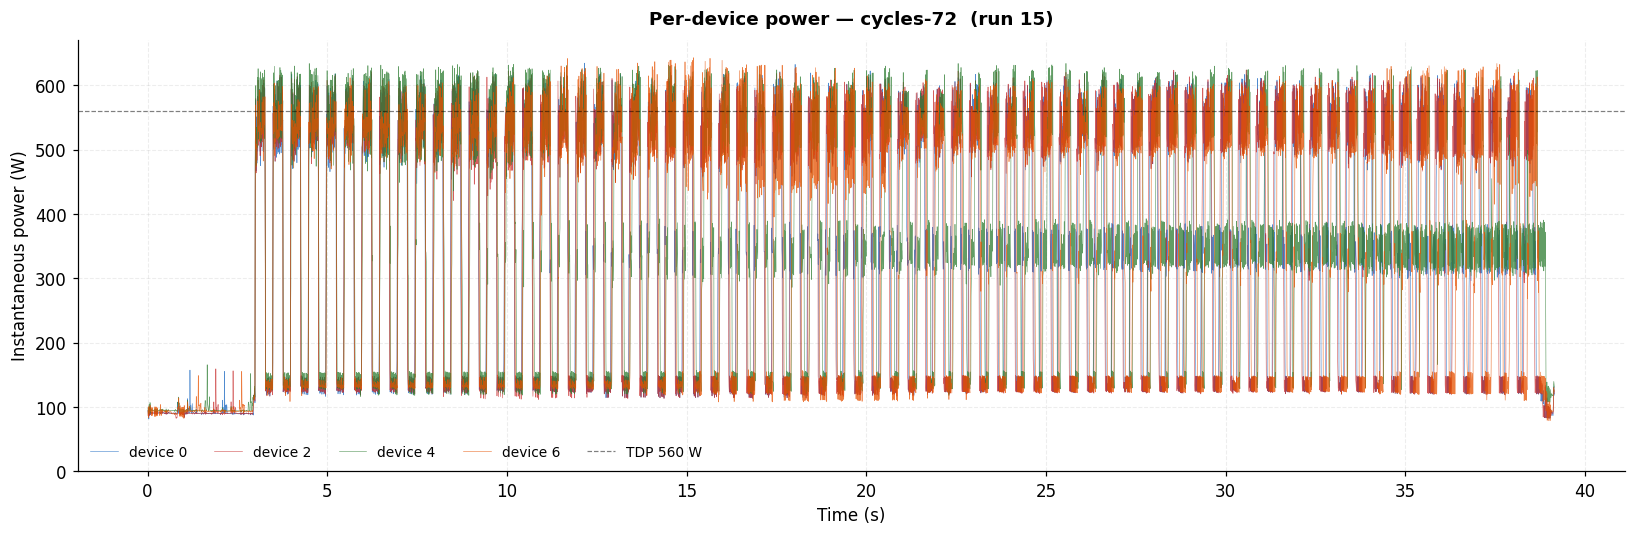

In [5]:
# Time-domain overlay for a mid-frequency probe run
PROBE = 15

DEVICE_COLORS = {'#1565C0': 0, '#C62828': 2, '#2E7D32': 4, '#E65100': 6}
DCOLORS = {d: c for c, d in DEVICE_COLORS.items()}

fig, ax = plt.subplots(figsize=(15, 5))
for d in GPU_DEVICES:
    t, p = device_power[d][PROBE]
    ax.plot(t, p, lw=0.4, alpha=0.75, label=f"device {d}", color=DCOLORS[d])

ax.axhline(TDP, color='black', lw=0.8, ls='--', alpha=0.5, label=f"TDP {TDP} W")
ax.set_xlabel("Time (s)")
ax.set_ylabel("Instantaneous power (W)")
ax.set_title(f"Per-device power — cycles-{cycle_counts[PROBE]}  (run {PROBE})")
ax.legend(ncol=5)
ax.set_ylim(0)
plt.tight_layout()
plt.show()

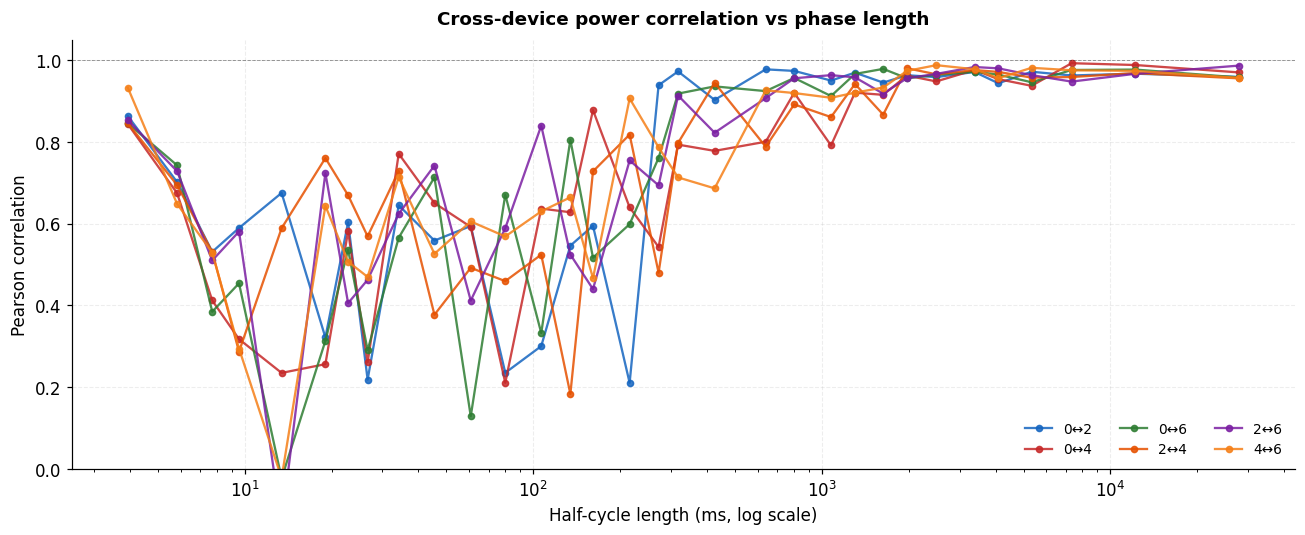

In [6]:
# Cross-device correlation vs half-cycle length
# For each run: build a matrix [4 x min_len] → Pearson corr 4x4
pairs = [(GPU_DEVICES[a], GPU_DEVICES[b])
         for a in range(len(GPU_DEVICES))
         for b in range(a + 1, len(GPU_DEVICES))]

half_ms_all = np.array([half_period_ms_of(i) for i in range(N_RUNS)])
order       = np.argsort(half_ms_all)

pair_corr = {p: [] for p in pairs}
for i in range(N_RUNS):
    L = min(len(device_power[d][i][1]) for d in GPU_DEVICES)
    mat = np.stack([device_power[d][i][1][:L] for d in GPU_DEVICES])  # 4 x L
    C = np.corrcoef(mat)
    for a_idx, a in enumerate(GPU_DEVICES):
        for b_idx, b in enumerate(GPU_DEVICES):
            if a_idx < b_idx:
                pair_corr[(a, b)].append(C[a_idx, b_idx])

fig, ax = plt.subplots(figsize=(12, 5))
pair_colors = ['#1565C0', '#C62828', '#2E7D32', '#E65100', '#7B1FA2', '#F57F17']
for (a, b), col in zip(pairs, pair_colors):
    corr = np.array(pair_corr[(a, b)])[order]
    ax.semilogx(half_ms_all[order], corr, '-o', lw=1.5, ms=4,
                color=col, alpha=0.85, label=f"{a}↔{b}")

ax.axhline(1.0, color='black', lw=0.6, ls='--', alpha=0.4)
ax.set_xlabel("Half-cycle length (ms, log scale)")
ax.set_ylabel("Pearson correlation")
ax.set_title("Cross-device power correlation vs phase length")
ax.set_ylim(0, 1.05)
ax.legend(ncol=3)
plt.tight_layout()
plt.show()

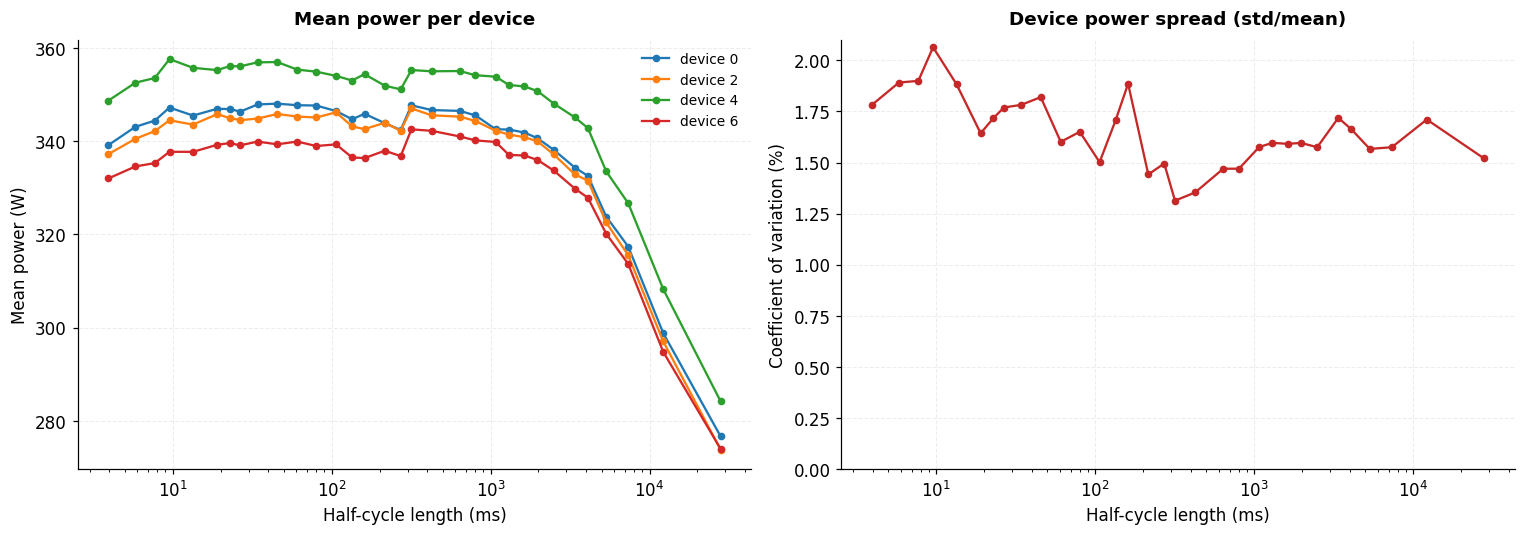

In [7]:
# Device-to-device spread: std / mean of mean powers across devices, per run
device_mean_powers = []
for i in range(N_RUNS):
    means = [float(device_power[d][i][1].mean()) for d in GPU_DEVICES]
    device_mean_powers.append(means)

device_mean_powers = np.array(device_mean_powers)  # N_RUNS x 4
cv = device_mean_powers.std(axis=1) / device_mean_powers.mean(axis=1)  # coefficient of variation

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: mean power per device across sweep
for d_idx, d in enumerate(GPU_DEVICES):
    axes[0].semilogx(half_ms_all[order], device_mean_powers[order, d_idx],
                     '-o', lw=1.5, ms=4, label=f"device {d}")
axes[0].set_xlabel("Half-cycle length (ms)")
axes[0].set_ylabel("Mean power (W)")
axes[0].set_title("Mean power per device")
axes[0].legend()

# Right: coefficient of variation
axes[1].semilogx(half_ms_all[order], cv[order] * 100, '-o',
                 color='#C62828', lw=1.5, ms=4)
axes[1].set_xlabel("Half-cycle length (ms)")
axes[1].set_ylabel("Coefficient of variation (%)")
axes[1].set_title("Device power spread (std/mean)")
axes[1].set_ylim(0)

plt.tight_layout()
plt.show()

## 5 · Transfer function and −3 dB bandwidth

At each drive fundamental $f_0$ we measure the ratio
$|H(f_0)| = \text{measured amplitude} / \text{ideal amplitude}$
and collect that point on a composite Bode plot. The −3 dB bandwidth
is where $|H| = 1/\sqrt{2} \approx 0.707$.

In [8]:
def amplitude_spectrum(t, p, t_skip_head=3.0, t_skip_tail=1.0,
                       fs_max=500.0, dt=None):
    t, p = np.asarray(t, float), np.asarray(p, float)
    m = (t >= t[0] + t_skip_head) & (t <= t[-1] - t_skip_tail)
    t, p = t[m], p[m]
    if len(t) < 64:
        return np.array([]), np.array([])
    if dt is None:
        dt = np.median(np.diff(t))
    fs = min(1.0 / dt, fs_max)
    tu = np.arange(t[0], t[-1], 1.0 / fs)
    pu = np.interp(tu, t, p)
    pd = signal.detrend(pu, type='linear')
    w  = signal.windows.hann(len(pd))
    spec = np.fft.rfft(pd * w)
    freq = np.fft.rfftfreq(len(pd), 1.0 / fs)
    mag  = (2.0 / w.sum()) * np.abs(spec)
    return freq, mag


def square_wave_amplitude(t, p, t_skip_head=3.0, t_skip_tail=1.0):
    t, p = np.asarray(t, float), np.asarray(p, float)
    m = (t >= t[0] + t_skip_head) & (t <= t[-1] - t_skip_tail)
    p = p[m]
    if len(p) < 64:
        return 0.0
    return 0.5 * (np.percentile(p, 95) - np.percentile(p, 5))


def measured_at(freq, mag, f_target, half_window=2):
    idx = int(np.argmin(np.abs(freq - f_target)))
    lo, hi = max(0, idx - half_window), min(len(mag), idx + half_window + 1)
    return mag[lo:hi].max()

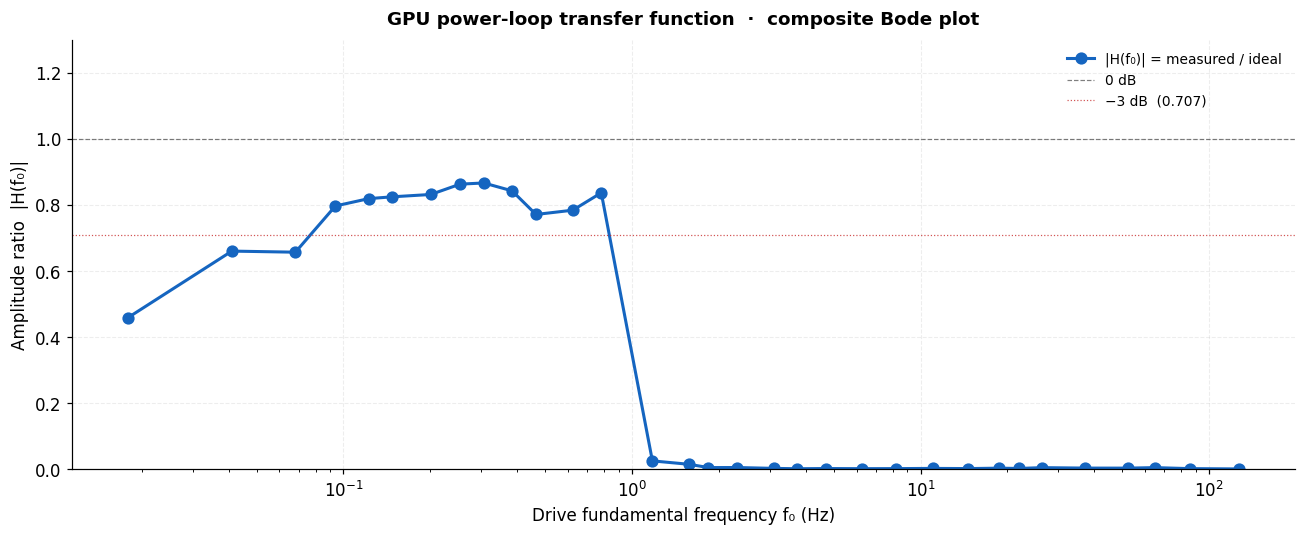

In [9]:
# Build composite Bode data: one (f0, ratio) point per run
tf_freq   = []   # fundamental frequency of each run
tf_ratio  = []   # measured / ideal amplitude at f0
tf_amp_ideal = []
tf_amp_meas  = []

for i, (t, p) in enumerate(combined_power):
    f0 = f0_of(i)
    fg, mg = amplitude_spectrum(t, p, fs_max=500.0, dt=0.001)
    A = square_wave_amplitude(t, p)
    if not len(fg) or A <= 0:
        continue
    ideal_f0 = 4.0 * A / np.pi      # fundamental coefficient of a square wave
    meas_f0  = measured_at(fg, mg, f0)
    ratio    = meas_f0 / ideal_f0 if ideal_f0 > 0 else np.nan
    tf_freq.append(f0)
    tf_ratio.append(ratio)
    tf_amp_ideal.append(ideal_f0)
    tf_amp_meas.append(meas_f0)

tf_freq  = np.array(tf_freq)
tf_ratio = np.array(tf_ratio)
sort_idx = np.argsort(tf_freq)
tf_freq_s  = tf_freq[sort_idx]
tf_ratio_s = tf_ratio[sort_idx]

fig, ax = plt.subplots(figsize=(12, 5))
ax.semilogx(tf_freq_s, tf_ratio_s, '-o', color='#1565C0', lw=2, ms=7,
            label='|H(f₀)| = measured / ideal')
ax.axhline(1.0,          color='black',  lw=0.8, ls='--', alpha=0.5, label='0 dB')
ax.axhline(1/np.sqrt(2), color='#C62828', lw=0.8, ls=':', alpha=0.8, label='−3 dB  (0.707)')
ax.set_xlabel("Drive fundamental frequency f₀ (Hz)")
ax.set_ylabel("Amplitude ratio  |H(f₀)|")
ax.set_title("GPU power-loop transfer function  ·  composite Bode plot")
ax.set_ylim(0, 1.3)
ax.legend()
plt.tight_layout()
plt.show()

In [10]:
# Estimate -3dB frequency by linear interpolation across the 0.707 crossing
target = 1.0 / np.sqrt(2)
f3dB = np.nan

valid = ~np.isnan(tf_ratio_s)
f_v, r_v = tf_freq_s[valid], tf_ratio_s[valid]

for k in range(len(r_v) - 1):
    if (r_v[k] >= target) and (r_v[k + 1] < target):
        frac = (target - r_v[k]) / (r_v[k + 1] - r_v[k])
        f3dB = np.exp(np.log(f_v[k]) + frac * (np.log(f_v[k + 1]) - np.log(f_v[k])))
        break

if np.isfinite(f3dB):
    print(f"Estimated −3 dB bandwidth:  {f3dB:.3f} Hz")
    print(f"Corresponding half-cycle:   {1000/(2*f3dB):.1f} ms")
else:
    print("−3 dB crossing not found in the sweep range.")

Estimated −3 dB bandwidth:  0.835 Hz
Corresponding half-cycle:   598.8 ms


## 6 · Control-loop model fitting

We model the GPU power-management loop as a first-order low-pass filter:

$$|H(f)| = \frac{1}{\sqrt{1 + (f / f_c)^2}}$$

and fit $f_c$ (corner frequency = bandwidth) to the composite Bode data.
A perfect first-order system would yield a straight $-20\text{ dB/decade}$
slope above $f_c$; deviations indicate higher-order dynamics.

Fitted corner frequency  fc = 0.412 Hz
Fitted time constant      τ = 386.3 ms


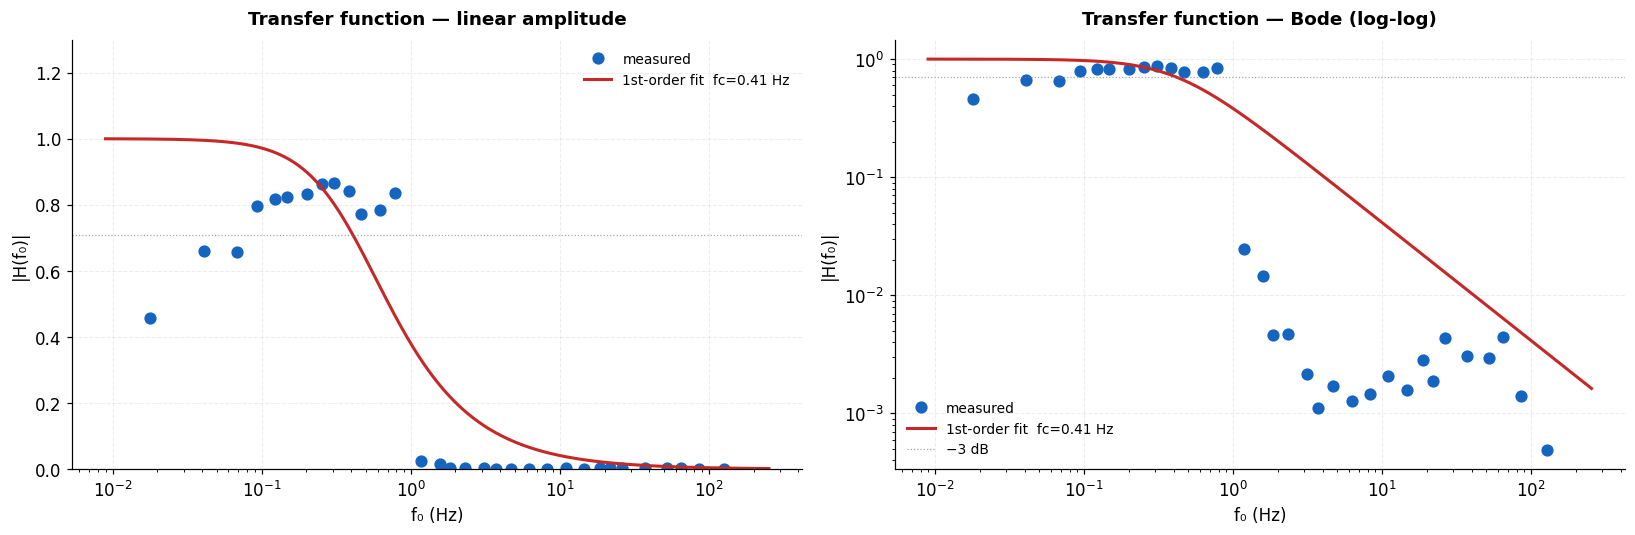

In [11]:
def first_order_lp(f, fc):
    return 1.0 / np.sqrt(1.0 + (f / fc) ** 2)


valid = np.isfinite(tf_ratio_s) & (tf_ratio_s > 0)
f_fit, r_fit = tf_freq_s[valid], tf_ratio_s[valid]

try:
    popt, pcov = curve_fit(first_order_lp, f_fit, r_fit,
                           p0=[f3dB if np.isfinite(f3dB) else 1.0],
                           bounds=(0.01, 1000))
    fc_fit  = popt[0]
    tau_fit = 1.0 / (2 * np.pi * fc_fit)
    print(f"Fitted corner frequency  fc = {fc_fit:.3f} Hz")
    print(f"Fitted time constant      τ = {tau_fit*1000:.1f} ms")
except RuntimeError:
    fc_fit, tau_fit = np.nan, np.nan
    print("Curve fit did not converge.")

f_dense = np.logspace(np.log10(f_v.min()) - 0.3,
                      np.log10(f_v.max()) + 0.3, 300)

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Left: linear amplitude
ax = axes[0]
ax.semilogx(tf_freq_s, tf_ratio_s, 'o', color='#1565C0', ms=7, label='measured')
if np.isfinite(fc_fit):
    ax.semilogx(f_dense, first_order_lp(f_dense, fc_fit),
                color='#C62828', lw=2, label=f'1st-order fit  fc={fc_fit:.2f} Hz')
ax.axhline(1/np.sqrt(2), color='grey', lw=0.8, ls=':', alpha=0.7)
ax.set_xlabel("f₀ (Hz)")
ax.set_ylabel("|H(f₀)|")
ax.set_title("Transfer function — linear amplitude")
ax.set_ylim(0, 1.3)
ax.legend()

# Right: log-log (Bode magnitude)
ax = axes[1]
ax.loglog(tf_freq_s[tf_ratio_s > 0], tf_ratio_s[tf_ratio_s > 0],
          'o', color='#1565C0', ms=7, label='measured')
if np.isfinite(fc_fit):
    ax.loglog(f_dense, first_order_lp(f_dense, fc_fit),
              color='#C62828', lw=2, label=f'1st-order fit  fc={fc_fit:.2f} Hz')
ax.axhline(1/np.sqrt(2), color='grey', lw=0.8, ls=':', alpha=0.7, label='−3 dB')
ax.set_xlabel("f₀ (Hz)")
ax.set_ylabel("|H(f₀)|")
ax.set_title("Transfer function — Bode (log-log)")
ax.legend()

plt.tight_layout()
plt.show()

## 7 · Cycle-folded waveforms and ridgeline view

Folding all cycles onto a single $[0,1)$ phase axis reveals the average
hot/cold shape per run. The ridgeline view stacks the median profiles
in order of phase length, making the shape transition across the sweep
obvious at a glance.

In [12]:
def fold_cycles(t, y, n_cycles, t_skip_head=3.0, t_skip_tail=1.0, n_phase_bins=400):
    t = np.asarray(t, dtype=float)
    y = np.asarray(y, dtype=float)
    mask = (t >= t[0] + t_skip_head) & (t <= t[-1] - t_skip_tail)
    t, y = t[mask], y[mask]
    if len(t) < 64 or n_cycles < 1:
        return None
    naive_period = (t[-1] - t[0]) / n_cycles

    def objective(p):
        ph = ((t - t[0]) / p) % 1.0
        means, _, _ = binned_statistic(ph, y, statistic='mean', bins=50)
        return -np.nanvar(means)

    res = minimize_scalar(objective,
                          bounds=(naive_period * 0.95, naive_period * 1.05),
                          method='bounded')
    best_period = res.x if res.success else naive_period

    phase    = ((t - t[0]) / best_period) % 1.0
    cycle_id = ((t - t[0]) // best_period).astype(int)
    phase_grid = np.linspace(0, 1, n_phase_bins, endpoint=False)
    n_used  = max(1, int(cycle_id.max()) + 1)
    stack   = np.full((n_used, n_phase_bins), np.nan)

    for k in range(n_used):
        sel = cycle_id == k
        if sel.sum() < 4:
            continue
        order = np.argsort(phase[sel])
        ph_k  = phase[sel][order]
        y_k   = y[sel][order]
        _, uniq = np.unique(ph_k, return_index=True)
        if len(uniq) < 4:
            continue
        stack[k] = np.interp(phase_grid, ph_k[uniq], y_k[uniq])

    if np.all(np.isnan(stack)):
        return None

    return dict(
        phase=phase_grid,
        period_s=best_period,
        stack=stack,
        median=np.nanmedian(stack, axis=0),
        p10=np.nanpercentile(stack, 10, axis=0),
        p90=np.nanpercentile(stack, 90, axis=0),
        n_cycles_used=int(np.sum(~np.all(np.isnan(stack), axis=1))),
    )


def align_cold_first(folded, min_swing_W=30.0):
    if folded is None:
        return None
    m      = folded['median']
    n      = len(m)
    swing  = float(np.nanmax(m) - np.nanmin(m))
    if swing < min_swing_W or n < 8:
        return {**folded, 'phase_shift': 0, 'align_quality': 0.0,
                'detected_swing_W': swing}
    centered = np.nan_to_num(m, nan=np.nanmean(m)) - m.mean()
    half = n // 2
    ref  = np.concatenate([-np.ones(half), np.ones(n - half)])
    corr = np.real(np.fft.ifft(np.fft.fft(centered) * np.conj(np.fft.fft(ref))))
    lag  = int(np.argmax(corr))
    out  = dict(folded)
    for key in ('median', 'p10', 'p90'):
        out[key] = np.roll(folded[key], -lag)
    out['stack']            = np.roll(folded['stack'], -lag, axis=1)
    out['phase_shift']      = lag
    out['align_quality']    = float(corr[lag] / (np.abs(centered).sum() or 1))
    out['detected_swing_W'] = swing
    return out


# Pre-compute all folded profiles
folded_all = [
    align_cold_first(fold_cycles(t, p, cycle_counts[i]))
    for i, (t, p) in enumerate(combined_power)
]

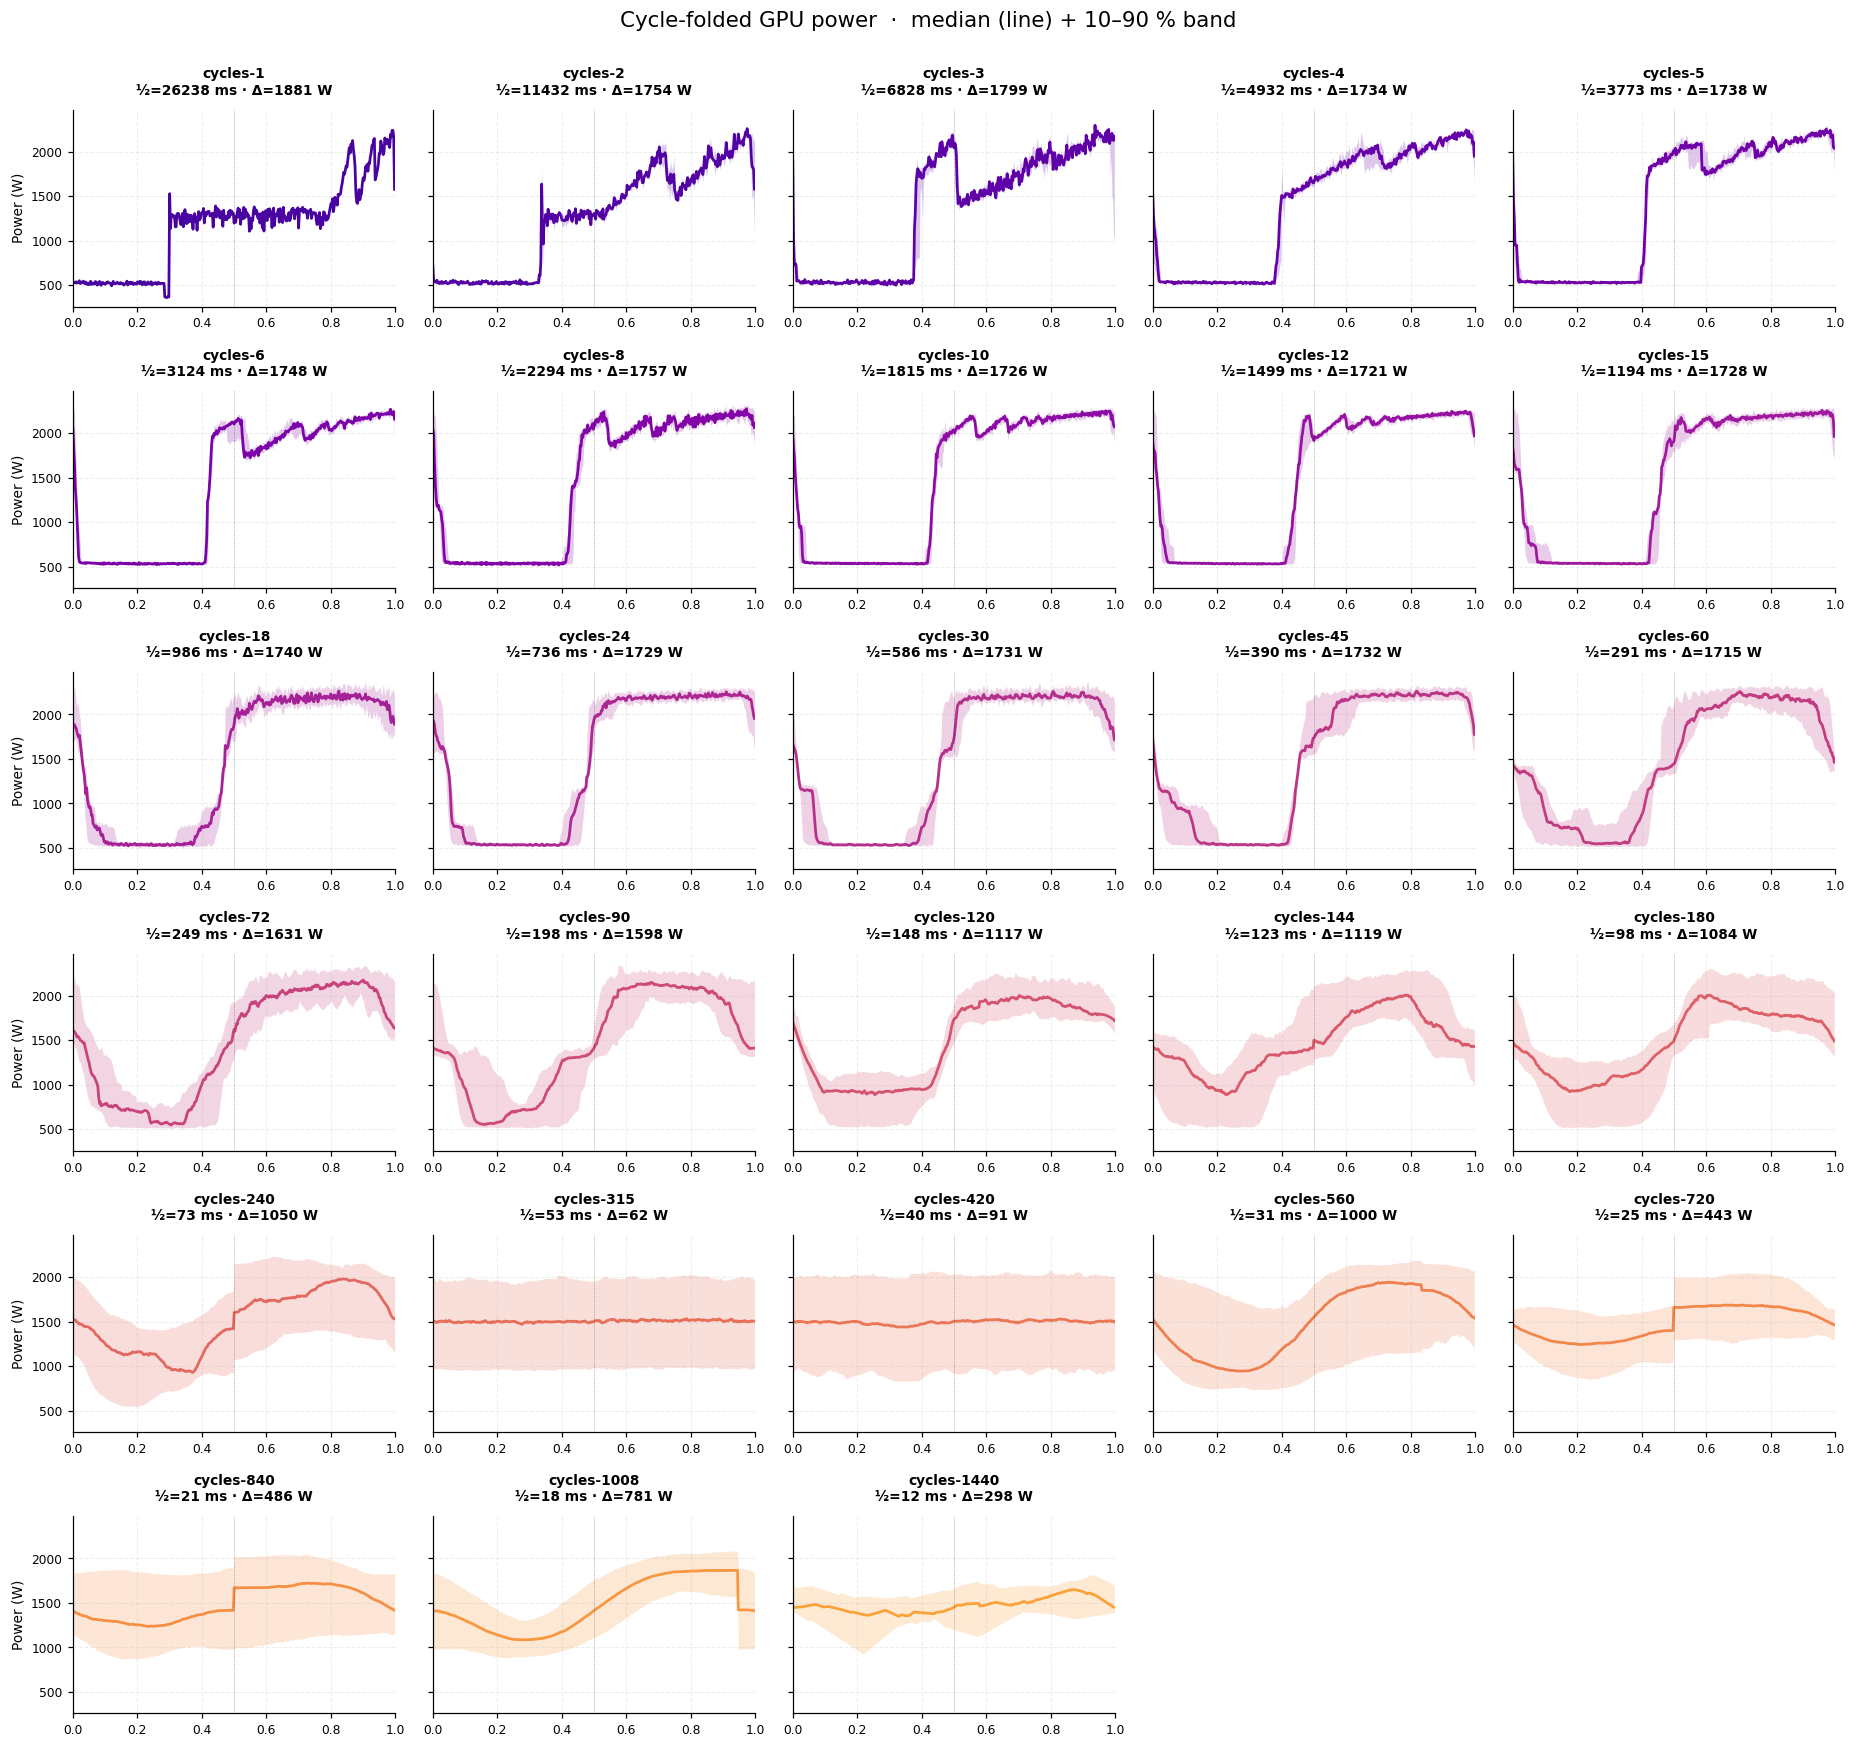

In [13]:
# Small-multiples grid
def grid_shape(n, ncols=5):
    return (n + ncols - 1) // ncols, ncols

nrows, ncols = grid_shape(N_RUNS)
fig, axes = plt.subplots(nrows, ncols, figsize=(17, nrows * 2.6), sharey=True)
fig.suptitle("Cycle-folded GPU power  ·  median (line) + 10–90 % band",
             fontsize=14, y=1.00)

for i, ax in enumerate(axes.flat):
    if i >= N_RUNS:
        ax.set_visible(False); continue
    fold = folded_all[i]
    if fold is None:
        ax.set_visible(False); continue
    ax.fill_between(fold['phase'], fold['p10'], fold['p90'],
                    color=PALETTE[i], alpha=0.22, lw=0)
    ax.plot(fold['phase'], fold['median'], color=PALETTE[i], lw=1.8)
    ax.axvline(0.5, color='black', lw=0.5, ls=':', alpha=0.45)
    half_ms = fold['period_s'] * 500
    ax.set_title(f"cycles-{cycle_counts[i]}\n"
                 f"½={half_ms:.0f} ms · Δ={fold['detected_swing_W']:.0f} W",
                 fontsize=9)
    ax.set_xlim(0, 1)
    ax.tick_params(labelsize=8)
    if i % ncols == 0:
        ax.set_ylabel("Power (W)", fontsize=9)
    if i // ncols == nrows - 1:
        ax.set_xlabel("Phase  (0=cold, 0.5=hot)", fontsize=9)

plt.tight_layout()
plt.show()

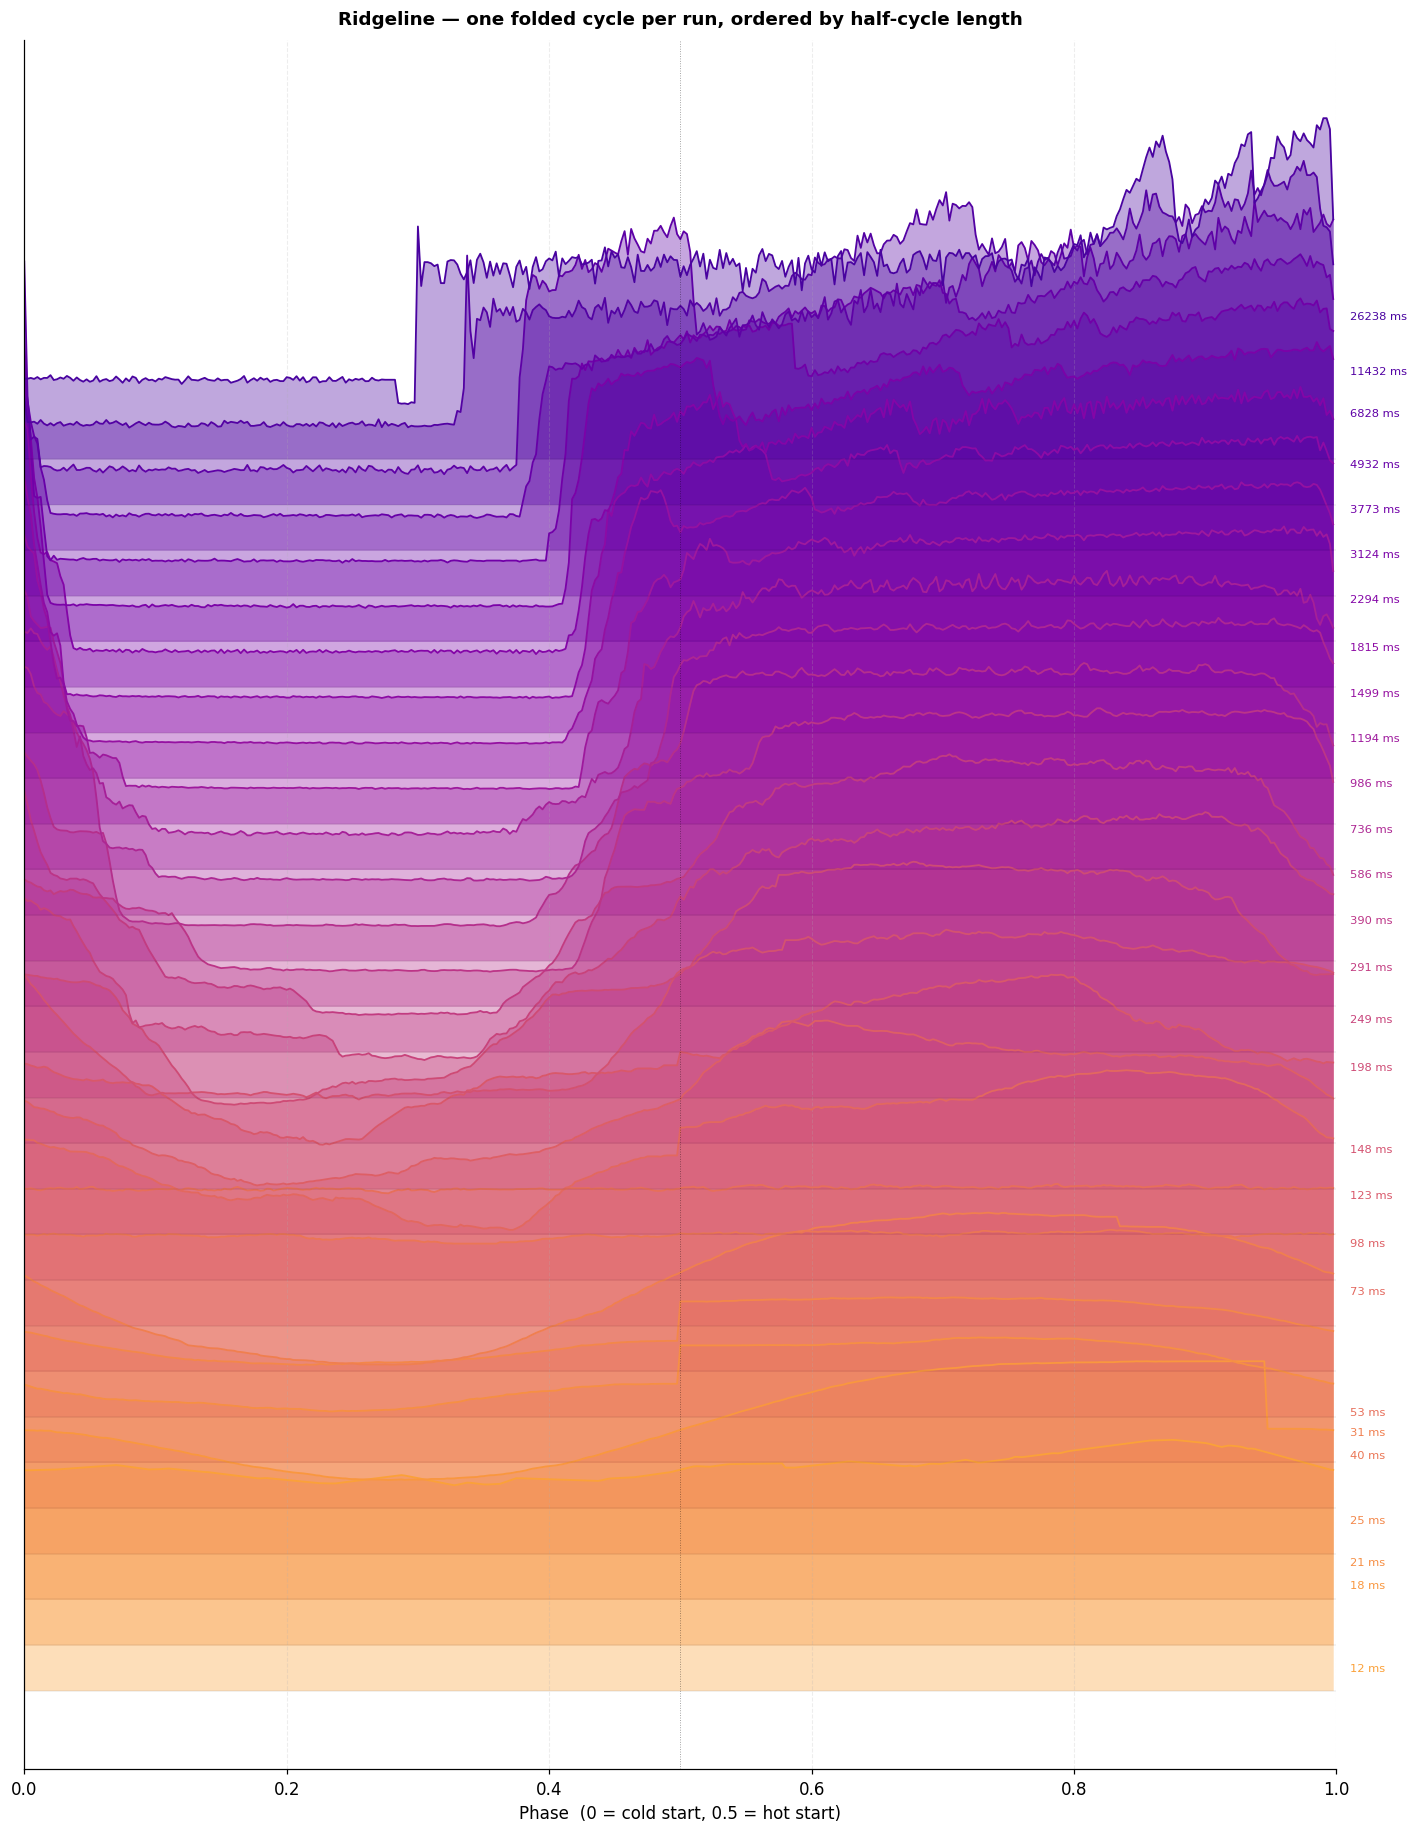

In [14]:
# Ridgeline / joy-plot: stacked median profiles, ordered by half-cycle length
valid_idx = [i for i in order if folded_all[i] is not None]
n_valid   = len(valid_idx)
spacing   = 300   # W vertical offset between ridges

fig, ax = plt.subplots(figsize=(13, max(6, n_valid * 0.6)))

for rank, i in enumerate(valid_idx):
    fold   = folded_all[i]
    ph     = fold['phase']
    med    = fold['median']
    offset = rank * spacing
    color  = PALETTE[i]
    ax.fill_between(ph, offset, med + offset,
                    color=color, alpha=0.35, lw=0)
    ax.plot(ph, med + offset, color=color, lw=1.2)
    ax.axhline(offset, color='black', lw=0.2, alpha=0.3)
    hms = fold['period_s'] * 500
    ax.text(1.01, offset + fold['detected_swing_W'] / 2,
            f"{hms:.0f} ms", va='center', ha='left',
            fontsize=7.5, color=color)

ax.axvline(0.5, color='black', lw=0.6, ls=':', alpha=0.4)
ax.set_xlim(0, 1)
ax.set_xlabel("Phase  (0 = cold start, 0.5 = hot start)")
ax.set_ylabel("Power (W, offset by run)")
ax.set_title("Ridgeline — one folded cycle per run, ordered by half-cycle length")
ax.yaxis.set_visible(False)
plt.tight_layout()
plt.show()

## 8 · Rise and fall time analysis

From each folded median profile, measure the 10→90 % **rise time** (cold→hot
edge) and the 90→10 % **fall time** (hot→cold edge). The time axis is
recovered from phase by multiplying by the fitted period.

If the GPU had an instantaneous response, both times would be zero;
a real control loop imposes a finite slew rate that sets a hard floor
on the achievable modulation depth at high drive frequencies.

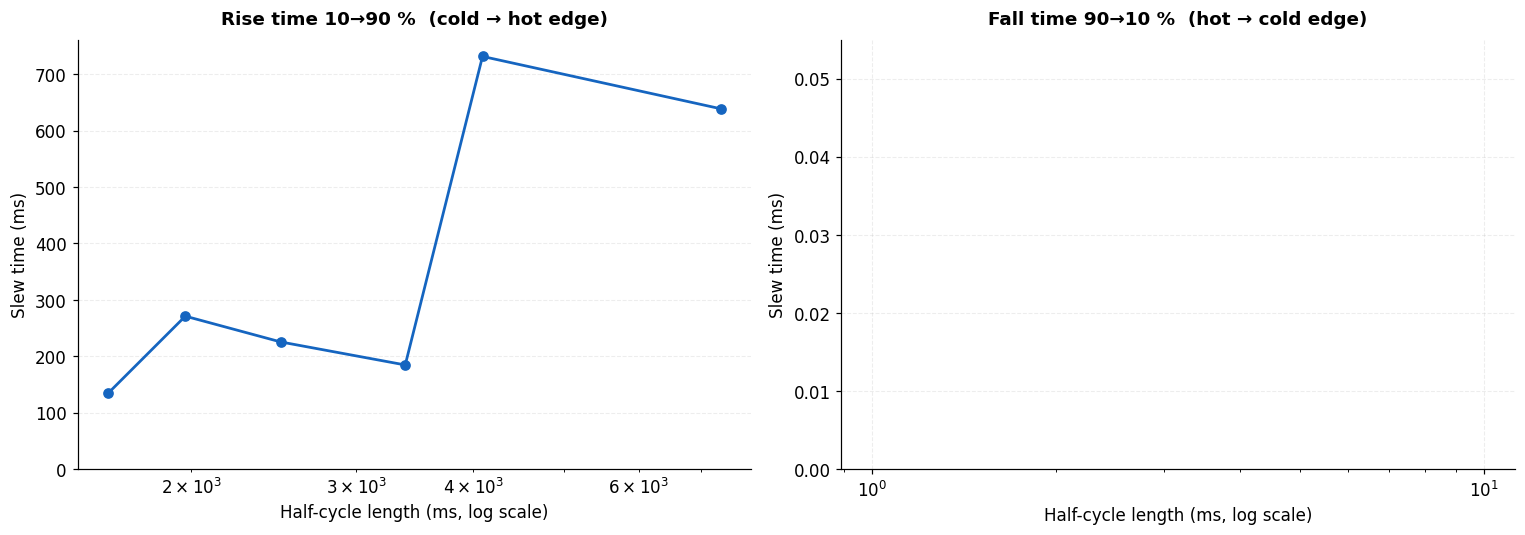

In [15]:
def slew_times(fold, min_swing_W=50.0):
    """Return (rise_ms, fall_ms) from a folded profile, or (nan, nan)."""
    if fold is None or fold.get('detected_swing_W', 0) < min_swing_W:
        return np.nan, np.nan
    med    = fold['median']
    ph     = fold['phase']
    T_s    = fold['period_s']
    lo, hi = np.nanpercentile(med, 10), np.nanpercentile(med, 90)
    span   = hi - lo
    if span < min_swing_W:
        return np.nan, np.nan
    p10, p90 = lo + 0.10 * span, lo + 0.90 * span

    # Rising edge: first crossing of p10 after phase 0, then crossing of p90
    def first_cross_phase(threshold, start_ph, end_ph, above=True):
        mask = (ph >= start_ph) & (ph < end_ph)
        seg  = med[mask]
        ph_seg = ph[mask]
        for k in range(len(seg) - 1):
            crosses = (seg[k] < threshold <= seg[k + 1]) if above else (seg[k] >= threshold > seg[k + 1])
            if crosses:
                frac = (threshold - seg[k]) / (seg[k + 1] - seg[k])
                return ph_seg[k] + frac * (ph_seg[k + 1] - ph_seg[k])
        return np.nan

    ph_10_rise = first_cross_phase(p10,  0.0, 0.5, above=True)
    ph_90_rise = first_cross_phase(p90,  0.0, 0.5, above=True)
    ph_90_fall = first_cross_phase(p90,  0.5, 1.0, above=False)
    ph_10_fall = first_cross_phase(p10,  0.5, 1.0, above=False)

    rise_ms = (ph_90_rise - ph_10_rise) * T_s * 1000 if np.isfinite(ph_10_rise) and np.isfinite(ph_90_rise) else np.nan
    fall_ms = (ph_10_fall - ph_90_fall) * T_s * 1000 if np.isfinite(ph_90_fall) and np.isfinite(ph_10_fall) else np.nan
    return rise_ms, fall_ms


slew_data = [slew_times(folded_all[i]) for i in range(N_RUNS)]
rise_ms = np.array([s[0] for s in slew_data])
fall_ms = np.array([s[1] for s in slew_data])
hp_ms   = np.array([half_period_ms_of(i) for i in range(N_RUNS)])
s_ord   = np.argsort(hp_ms)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, arr, label, color in [
    (axes[0], rise_ms, 'Rise time 10→90 %  (cold → hot edge)', '#1565C0'),
    (axes[1], fall_ms, 'Fall time 90→10 %  (hot → cold edge)', '#C62828'),
]:
    valid = np.isfinite(arr[s_ord])
    ax.semilogx(hp_ms[s_ord][valid], arr[s_ord][valid], '-o',
                color=color, lw=1.8, ms=6)
    ax.set_xlabel("Half-cycle length (ms, log scale)")
    ax.set_ylabel("Slew time (ms)")
    ax.set_title(label)
    ax.set_ylim(0)

plt.tight_layout()
plt.show()

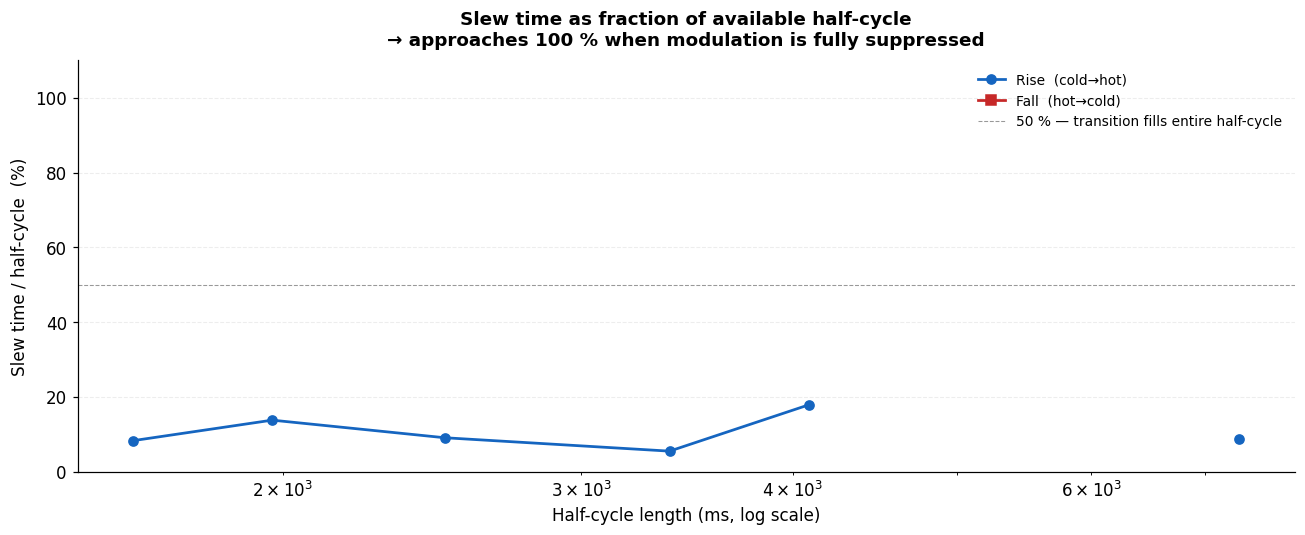

In [16]:
# Rise/fall time as a fraction of the half-cycle length
fig, ax = plt.subplots(figsize=(12, 5))

rise_frac = rise_ms[s_ord] / hp_ms[s_ord]
fall_frac = fall_ms[s_ord] / hp_ms[s_ord]

ax.semilogx(hp_ms[s_ord], rise_frac * 100, '-o', color='#1565C0', lw=1.8, ms=6,
            label='Rise  (cold→hot)')
ax.semilogx(hp_ms[s_ord], fall_frac * 100, '-s', color='#C62828', lw=1.8, ms=6,
            label='Fall  (hot→cold)')
ax.axhline(50, color='black', lw=0.7, ls='--', alpha=0.4,
           label='50 % — transition fills entire half-cycle')
ax.set_xlabel("Half-cycle length (ms, log scale)")
ax.set_ylabel("Slew time / half-cycle  (%)")
ax.set_title("Slew time as fraction of available half-cycle\n"
             "→ approaches 100 % when modulation is fully suppressed")
ax.set_ylim(0, 110)
ax.legend()
plt.tight_layout()
plt.show()

## 9 · Thermal baseline drift

At very high drive frequencies the GPU cannot fully cool down between
hot phases. This manifests as the **cold-phase floor** (minimum power
during the idle half) rising above the true idle baseline.

We extract the floor from the folded median (5th percentile of the
first-quarter phase, i.e. the cold half) and compare it to the floor
of the slowest runs.

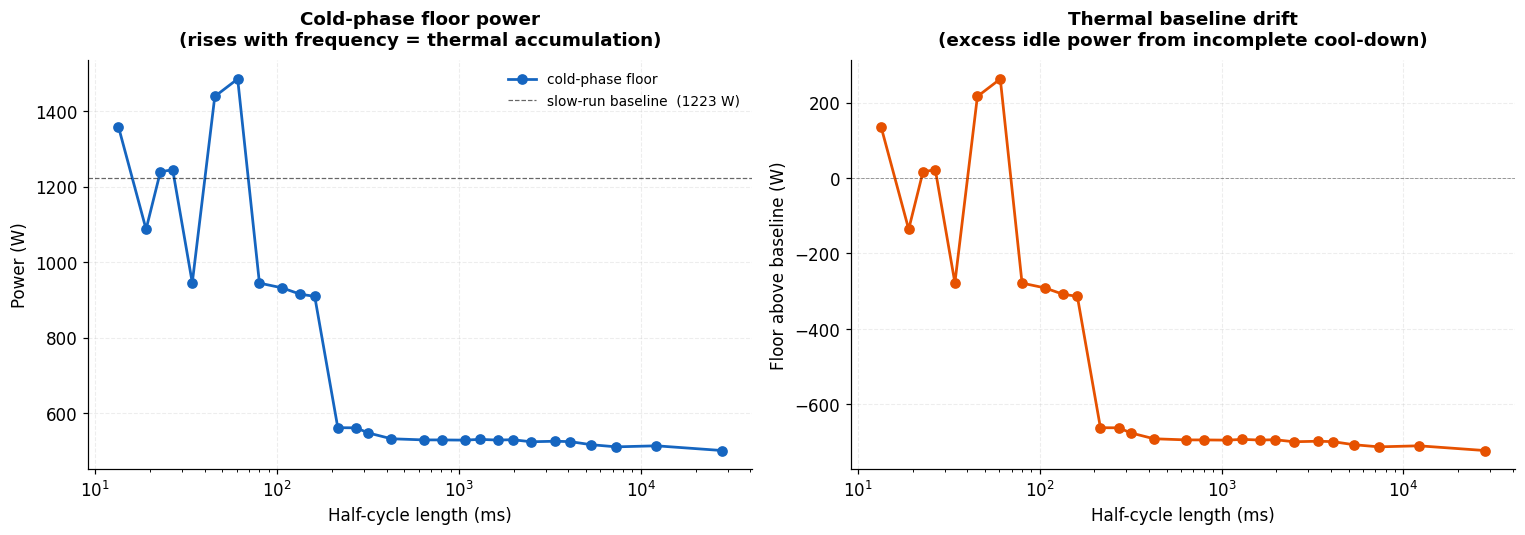

In [17]:
cold_floor_W  = []
hot_ceiling_W = []

for i in range(N_RUNS):
    fold = folded_all[i]
    if fold is None:
        cold_floor_W.append(np.nan)
        hot_ceiling_W.append(np.nan)
        continue
    med = fold['median']
    ph  = fold['phase']
    cold_seg = med[ph < 0.45]   # first half (cold phase after alignment)
    hot_seg  = med[ph > 0.55]   # second half (hot phase)
    cold_floor_W.append(float(np.nanpercentile(cold_seg, 5))  if len(cold_seg) else np.nan)
    hot_ceiling_W.append(float(np.nanpercentile(hot_seg,  95)) if len(hot_seg)  else np.nan)

cold_floor_W  = np.array(cold_floor_W)
hot_ceiling_W = np.array(hot_ceiling_W)

# Baseline: floor of the slowest runs (longest half-cycle = most recovery time)
n_baseline = max(1, N_RUNS // 5)
baseline_floor = np.nanmean(cold_floor_W[s_ord[:n_baseline]])

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ax = axes[0]
ax.semilogx(hp_ms[s_ord], cold_floor_W[s_ord], '-o',
            color='#1565C0', lw=1.8, ms=6, label='cold-phase floor')
ax.axhline(baseline_floor, color='black', lw=0.8, ls='--', alpha=0.6,
           label=f'slow-run baseline  ({baseline_floor:.0f} W)')
ax.set_xlabel("Half-cycle length (ms)")
ax.set_ylabel("Power (W)")
ax.set_title("Cold-phase floor power\n(rises with frequency = thermal accumulation)")
ax.legend()

ax = axes[1]
drift = cold_floor_W[s_ord] - baseline_floor
ax.semilogx(hp_ms[s_ord], drift, '-o',
            color='#E65100', lw=1.8, ms=6)
ax.axhline(0, color='black', lw=0.6, ls='--', alpha=0.4)
ax.set_xlabel("Half-cycle length (ms)")
ax.set_ylabel("Floor above baseline (W)")
ax.set_title("Thermal baseline drift\n(excess idle power from incomplete cool-down)")

plt.tight_layout()
plt.show()

## 10 · Power distribution across the sweep

Violin plots of the combined GPU power distribution for each run,
ordered by half-cycle length. Bimodal distributions (hot + cold peaks)
should appear for moderate frequencies, collapsing to a unimodal
distribution as the loop fails to track at either extreme.

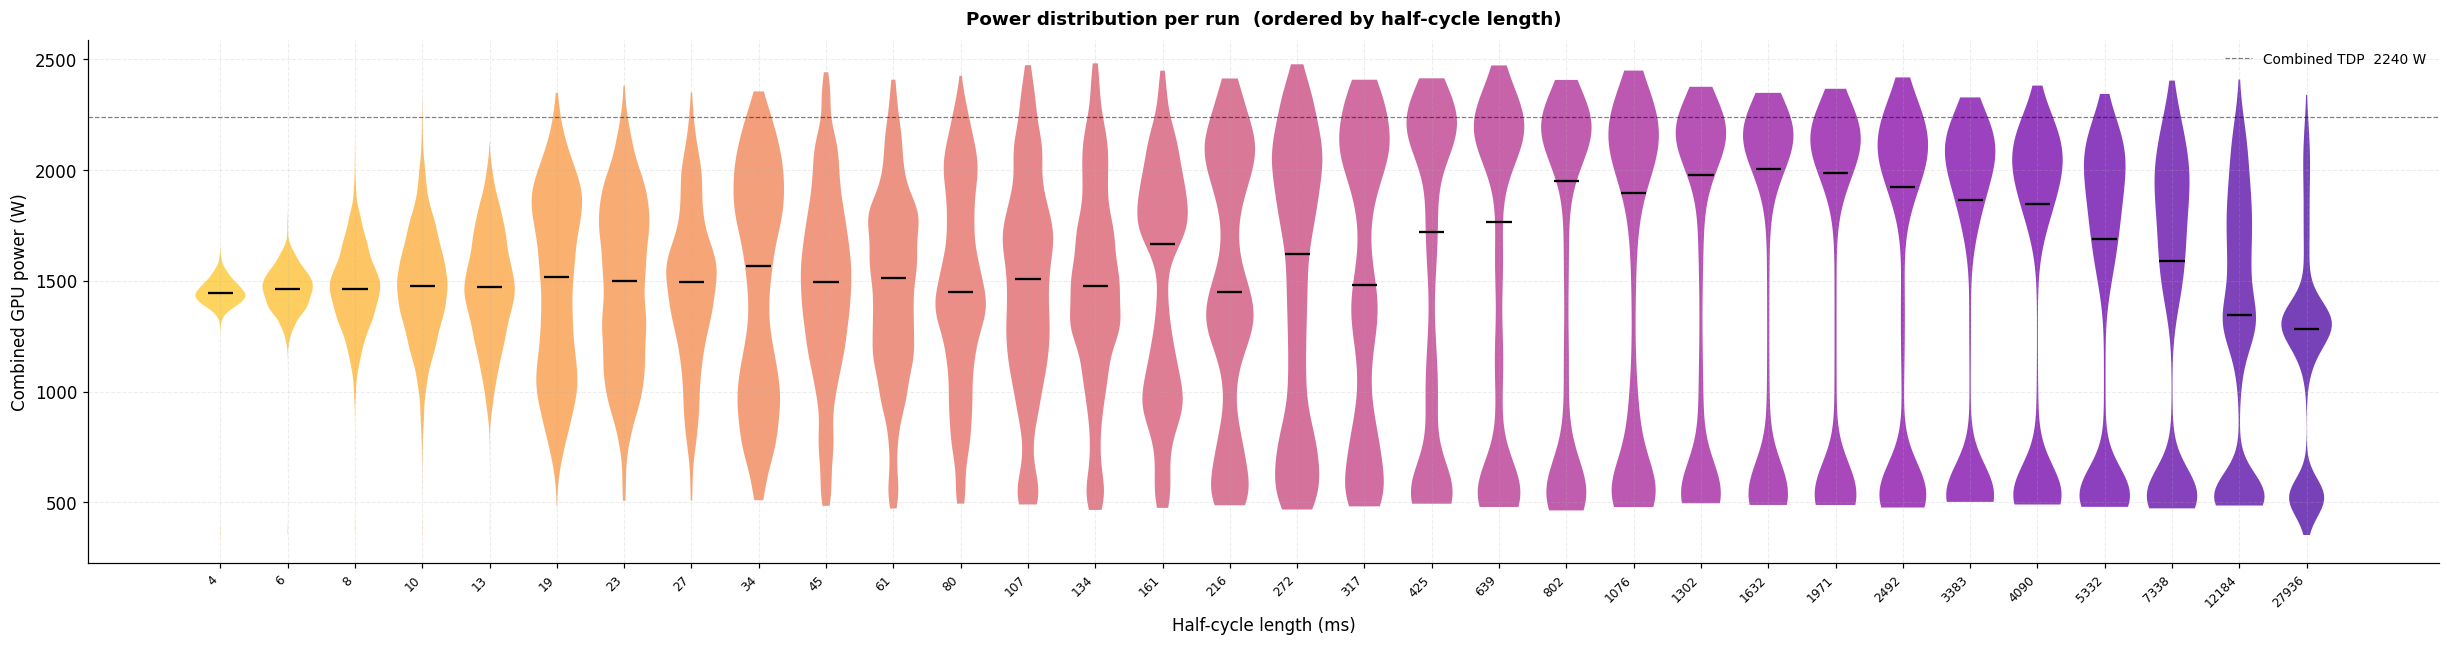

In [18]:
SKIP_HEAD, SKIP_TAIL = 3.0, 1.0

violin_data = []
violin_labels = []
for i in s_ord:
    t, p = combined_power[i]
    m = (t >= t[0] + SKIP_HEAD) & (t <= t[-1] - SKIP_TAIL)
    violin_data.append(p[m])
    violin_labels.append(f"{half_period_ms_of(i):.0f}")

fig, ax = plt.subplots(figsize=(max(12, N_RUNS * 0.7), 6))

parts = ax.violinplot(violin_data, positions=np.arange(len(violin_data)),
                      widths=0.75, showmedians=True,
                      showextrema=False)

for i, body in enumerate(parts['bodies']):
    body.set_facecolor(PALETTE[s_ord[i]])
    body.set_alpha(0.75)
parts['cmedians'].set_color('black')
parts['cmedians'].set_linewidth(1.5)

ax.axhline(TDP_TOTAL, color='black', lw=0.8, ls='--', alpha=0.5,
           label=f'Combined TDP  {TDP_TOTAL} W')
ax.set_xticks(np.arange(len(violin_data)))
ax.set_xticklabels(violin_labels, rotation=45, ha='right', fontsize=8)
ax.set_xlabel("Half-cycle length (ms)")
ax.set_ylabel("Combined GPU power (W)")
ax.set_title("Power distribution per run  (ordered by half-cycle length)")
ax.legend()
plt.tight_layout()
plt.show()

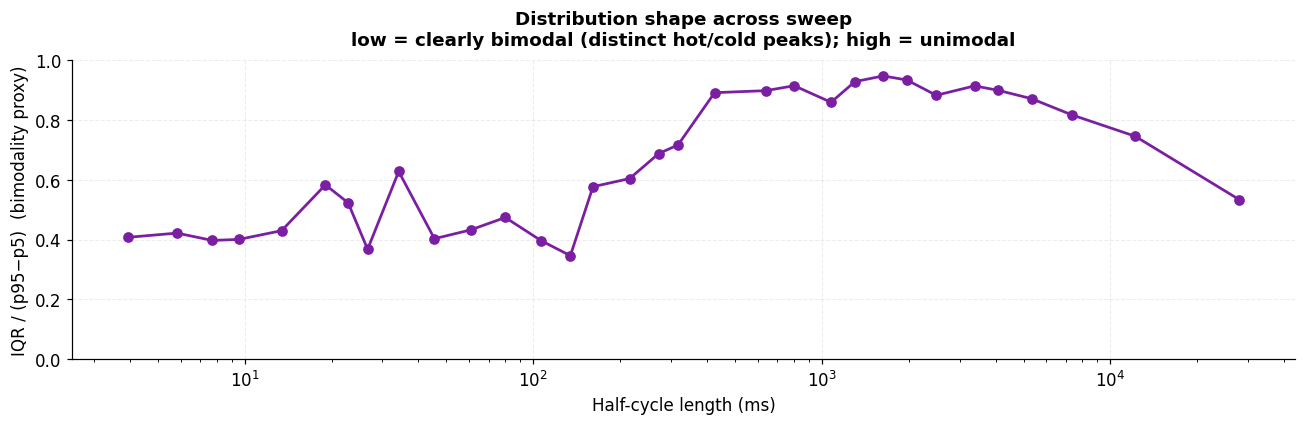

In [19]:
# Bimodality index: how clearly bimodal is each power distribution?
# Simple proxy: (p75 - p25) / (p95 - p5) — low value = flat/unimodal, high = bimodal
bimodality = []
for i in range(N_RUNS):
    t, p = combined_power[i]
    m = (t >= t[0] + SKIP_HEAD) & (t <= t[-1] - SKIP_TAIL)
    pv = p[m]
    span  = np.percentile(pv, 95) - np.percentile(pv, 5)
    iqr   = np.percentile(pv, 75) - np.percentile(pv, 25)
    bimodality.append(float(iqr / span) if span > 1 else np.nan)

bimodality = np.array(bimodality)

fig, ax = plt.subplots(figsize=(12, 4))
ax.semilogx(hp_ms[s_ord], bimodality[s_ord], '-o',
            color='#7B1FA2', lw=1.8, ms=6)
ax.set_xlabel("Half-cycle length (ms)")
ax.set_ylabel("IQR / (p95−p5)  (bimodality proxy)")
ax.set_title("Distribution shape across sweep\n"
             "low = clearly bimodal (distinct hot/cold peaks); high = unimodal")
ax.set_ylim(0, 1)
plt.tight_layout()
plt.show()

## 11 · Energy per cycle

How much energy (Joules) does one hot/cold cycle consume, and how does
that compare across the sweep?

* **Total energy per cycle** = integrated combined GPU power over one
  fitted period.
* **Ideal energy per cycle** = TDP_TOTAL × half-period (assume full
  TDP during hot, zero during cold — unrealistic but useful as a
  ceiling reference).
* **Energy efficiency** = actual / ideal — tends toward 1 for slow
  cycles and falls as the loop can't deliver full TDP in short phases.

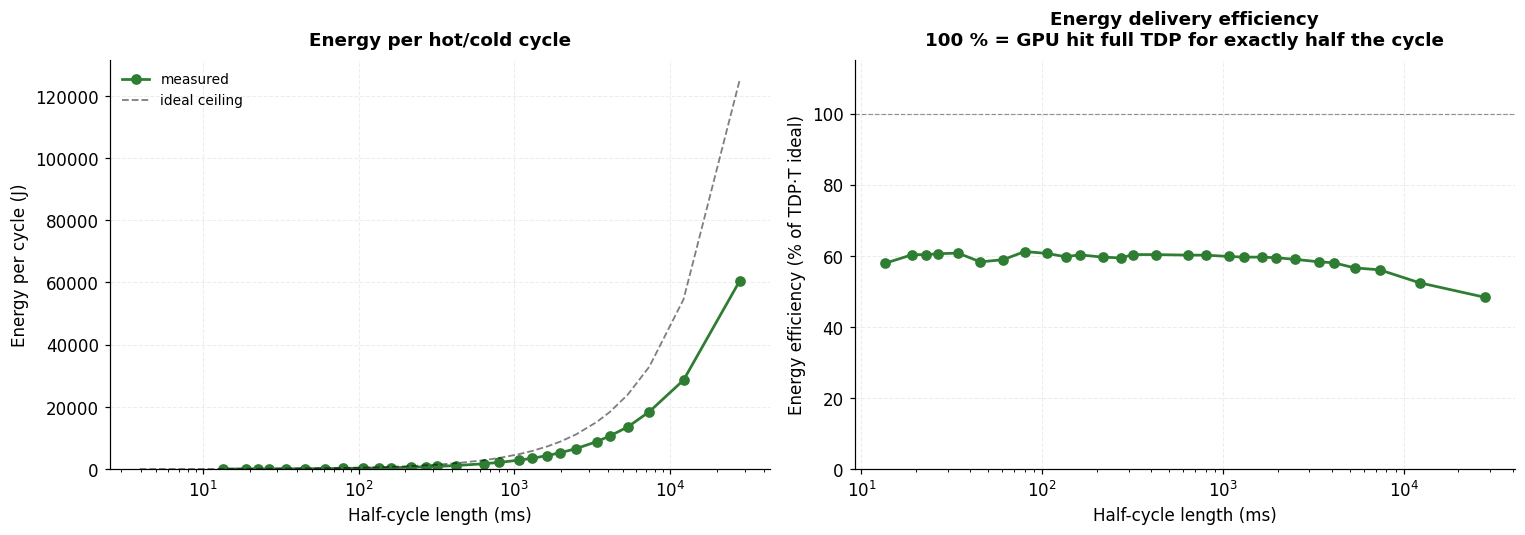

In [20]:
energy_per_cycle_J = []

for i, (t, p) in enumerate(combined_power):
    fold = folded_all[i]
    if fold is None:
        energy_per_cycle_J.append(np.nan)
        continue
    T  = fold['period_s']
    ph = fold['phase']
    med = fold['median']
    # Integrate median profile over one period
    dph = np.diff(ph)
    E   = float(np.nansum(med[:-1] * dph) * T)
    energy_per_cycle_J.append(E)

energy_per_cycle_J = np.array(energy_per_cycle_J)

# Ideal: TDP_TOTAL for exactly half the period
ideal_J = TDP_TOTAL * np.array([half_period_ms_of(i) / 1000.0 for i in range(N_RUNS)])
efficiency = energy_per_cycle_J / (ideal_J * 2)  # full-period ideal = 2 × half-TDP

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ax = axes[0]
ax.semilogx(hp_ms[s_ord], energy_per_cycle_J[s_ord], '-o',
            color='#2E7D32', lw=1.8, ms=6, label='measured')
ax.semilogx(hp_ms[s_ord], (ideal_J * 2)[s_ord], '--',
            color='black', lw=1.2, alpha=0.5, label='ideal ceiling')
ax.set_xlabel("Half-cycle length (ms)")
ax.set_ylabel("Energy per cycle (J)")
ax.set_title("Energy per hot/cold cycle")
ax.set_ylim(0)
ax.legend()

ax = axes[1]
ax.semilogx(hp_ms[s_ord], efficiency[s_ord] * 100, '-o',
            color='#2E7D32', lw=1.8, ms=6)
ax.axhline(100, color='black', lw=0.8, ls='--', alpha=0.4)
ax.set_xlabel("Half-cycle length (ms)")
ax.set_ylabel("Energy efficiency (% of TDP·T ideal)")
ax.set_title("Energy delivery efficiency\n"
             "100 % = GPU hit full TDP for exactly half the cycle")
ax.set_ylim(0, 115)

plt.tight_layout()
plt.show()

## 13 · Multi-harmonic Bode plot

The fundamental-only transfer function in § 5 uses one point per run.
Here we collect **every odd harmonic** of every run, giving a denser
Bode plot that reveals whether the roll-off follows the $1/f$ envelope
of a single-pole system or has a more complex shape (notches, bumps,
steeper-than-20 dB/decade slopes).

Each point is coloured by its harmonic order $k$ so aliasing artifacts
— where a high harmonic of a slow run lands at the same frequency as
the fundamental of a fast run — are easy to spot.

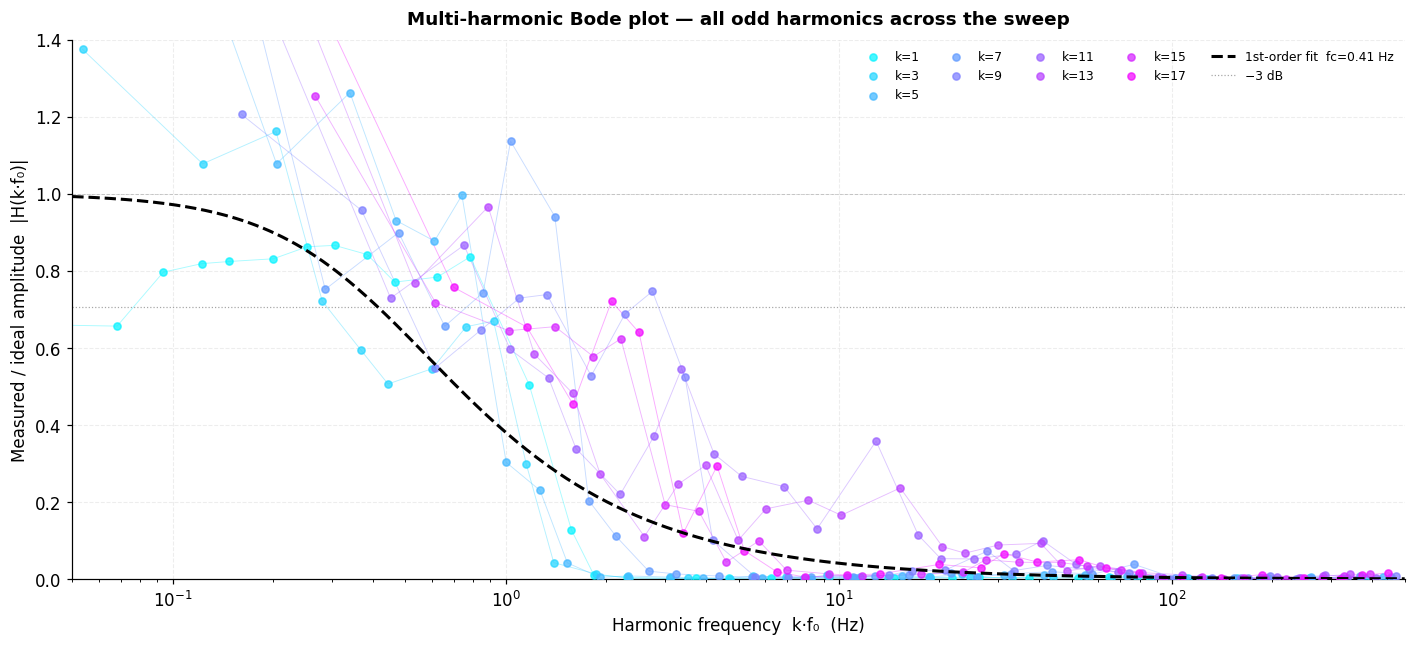

In [21]:
N_ODD_HARMONICS = 9   # k = 1, 3, 5, … 2N-1

all_freq_k   = []   # harmonic frequency (Hz)
all_ratio_k  = []   # measured / ideal ratio
all_k_order  = []   # harmonic index k (1, 3, 5, …)
all_run_idx  = []   # which run

for i, (t, p) in enumerate(combined_power):
    f0 = f0_of(i)
    fg, mg = amplitude_spectrum(t, p, fs_max=500.0, dt=0.001)
    A = square_wave_amplitude(t, p)
    if not len(fg) or A <= 0:
        continue

    for n in range(N_ODD_HARMONICS):
        k = 2 * n + 1
        fk = k * f0
        if fk > 480:
            break
        ideal_k = 4.0 * A / (np.pi * k)
        meas_k  = measured_at(fg, mg, fk, half_window=3)
        ratio_k = meas_k / ideal_k if ideal_k > 0 else np.nan
        all_freq_k.append(fk)
        all_ratio_k.append(ratio_k)
        all_k_order.append(k)
        all_run_idx.append(i)

all_freq_k  = np.array(all_freq_k)
all_ratio_k = np.array(all_ratio_k)
all_k_order = np.array(all_k_order)

k_vals   = sorted(set(all_k_order))
k_colors = plt.cm.cool(np.linspace(0.05, 0.95, len(k_vals)))

fig, ax = plt.subplots(figsize=(13, 6))

for k, col in zip(k_vals, k_colors):
    mask = all_k_order == k
    f_k  = all_freq_k[mask]
    r_k  = all_ratio_k[mask]
    sort = np.argsort(f_k)
    ax.scatter(f_k[sort], r_k[sort], s=22, color=col, alpha=0.75,
               label=f'k={k}', zorder=3)
    ax.semilogx(f_k[sort], r_k[sort], color=col, lw=0.6, alpha=0.35)

# Overlay first-order model fit from §6
if np.isfinite(fc_fit):
    f_dense = np.logspace(np.log10(0.05), np.log10(500), 400)
    ax.semilogx(f_dense, first_order_lp(f_dense, fc_fit),
                color='black', lw=2, ls='--',
                label=f'1st-order fit  fc={fc_fit:.2f} Hz', zorder=4)

ax.axhline(1/np.sqrt(2), color='grey', lw=0.8, ls=':', alpha=0.7, label='−3 dB')
ax.axhline(1.0,          color='grey', lw=0.6, ls='--', alpha=0.4)
ax.set_xscale('log')
ax.set_xlabel('Harmonic frequency  k·f₀  (Hz)')
ax.set_ylabel('Measured / ideal amplitude  |H(k·f₀)|')
ax.set_title('Multi-harmonic Bode plot — all odd harmonics across the sweep')
ax.set_xlim(0.05, 500)
ax.set_ylim(0, 1.4)
ax.legend(ncol=5, fontsize=8, loc='upper right')
plt.tight_layout()
plt.show()

## 14 · Rise / fall asymmetry

A symmetric control loop would heat and cool at the same rate. GPU power
management typically heats faster than it cools (thermal mass + conservative
ramp-down), so rise time < fall time. This section quantifies the asymmetry
as a function of drive period and checks whether it is frequency-dependent.

In [ ]:
valid_mask = np.isfinite(rise_ms) & np.isfinite(fall_ms)
asym_ratio = fall_ms / rise_ms               # > 1 → slower to cool
asym_diff  = fall_ms - rise_ms               # ms

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Left: rise vs fall scatter, coloured by half-period
c_vals = hp_ms[valid_mask]
if len(c_vals) > 0 and c_vals.min() > 0 and c_vals.min() < c_vals.max():
    lognorm = plt.matplotlib.colors.LogNorm(vmin=c_vals.min(), vmax=c_vals.max())
else:
    lognorm = None
sc = axes[0].scatter(rise_ms[valid_mask], fall_ms[valid_mask],
                     c=c_vals, norm=lognorm,
                     cmap='plasma', s=60, zorder=3)
cb = fig.colorbar(sc, ax=axes[0])
cb.set_label('Half-cycle length (ms)')
lim = max(np.nanmax(rise_ms), np.nanmax(fall_ms)) * 1.05
axes[0].plot([0, lim], [0, lim], 'k--', lw=0.8, alpha=0.5, label='symmetry line')
axes[0].set_xlabel('Rise time  10→90 %  (ms)')
axes[0].set_ylabel('Fall time  90→10 %  (ms)')
axes[0].set_title('Rise vs fall time\n(above diagonal = slower cool-down)')
axes[0].set_xlim(0, lim); axes[0].set_ylim(0, lim)
axes[0].legend()

# Centre: ratio vs half-period
axes[1].semilogx(hp_ms[s_ord], asym_ratio[s_ord], '-o',
                 color='#7B1FA2', lw=1.8, ms=6)
axes[1].axhline(1.0, color='black', lw=0.7, ls='--', alpha=0.5, label='symmetric')
axes[1].set_xlabel('Half-cycle length (ms)')
axes[1].set_ylabel('Fall time / rise time')
axes[1].set_title('Asymmetry ratio\n(1 = symmetric, >1 = slower cool-down)')
axes[1].set_ylim(0)
axes[1].legend()

# Right: absolute difference
axes[2].semilogx(hp_ms[s_ord], asym_diff[s_ord], '-o',
                 color='#00838F', lw=1.8, ms=6)
axes[2].axhline(0, color='black', lw=0.7, ls='--', alpha=0.5)
axes[2].set_xlabel('Half-cycle length (ms)')
axes[2].set_ylabel('Fall − rise  (ms)')
axes[2].set_title('Absolute asymmetry\n(positive = slower to cool)')

plt.tight_layout()
plt.show()

# Print summary
print("Rise / fall asymmetry summary:")
print(f"  Median ratio  fall/rise : {np.nanmedian(asym_ratio):.2f}×")
print(f"  Median diff   fall−rise : {np.nanmedian(asym_diff):.1f} ms")


## 15 · Phase-sweep heatmap

A 2-D heatmap where the x-axis is normalised phase $[0,1)$ and the
y-axis is the run index ordered by half-cycle length. Each row is the
median folded power profile. This gives an at-a-glance view of how the
waveform shape evolves across the entire frequency sweep — from sharp
square-wave transitions at slow speeds to a nearly flat response at high
drive frequencies.

In [ ]:
N_PHASE_BINS = 200
heatmap = np.full((N_RUNS, N_PHASE_BINS), np.nan)
ytick_vals, ytick_labels = [], []

for rank, i in enumerate(s_ord):
    fold = folded_all[i]
    if fold is None:
        continue
    # Resample median profile onto common N_PHASE_BINS grid
    ph_src = fold['phase']
    med_src = fold['median']
    ph_dst = np.linspace(0, 1, N_PHASE_BINS, endpoint=False)
    heatmap[rank] = np.interp(ph_dst, ph_src, np.nan_to_num(med_src, nan=np.nanmean(med_src)))
    if rank % max(1, N_RUNS // 10) == 0:
        ytick_vals.append(rank)
        ytick_labels.append(f"{half_period_ms_of(i):.0f} ms")

# Row-normalise so shape is comparable across rows (min→0, max→1)
row_min = np.nanmin(heatmap, axis=1, keepdims=True)
row_max = np.nanmax(heatmap, axis=1, keepdims=True)
heatmap_norm = (heatmap - row_min) / np.where(row_max > row_min, row_max - row_min, 1)

fig, axes = plt.subplots(1, 2, figsize=(16, 7))

raw_vmin, raw_vmax = np.nanmin(heatmap), np.nanmax(heatmap)
if not (np.isfinite(raw_vmin) and np.isfinite(raw_vmax) and raw_vmin < raw_vmax):
    raw_vmin, raw_vmax = 0, 1

for ax, data, title, cmap, vmin, vmax in [
    (axes[0], heatmap,      'Median folded power (W)',           'inferno',   raw_vmin, raw_vmax),
    (axes[1], heatmap_norm, 'Row-normalised  (0=cold, 1=hot)',   'RdYlBu_r',  0,        1),
]:
    im = ax.imshow(data, aspect='auto', origin='lower',
                   extent=[0, 1, -0.5, N_RUNS - 0.5],
                   cmap=cmap, interpolation='nearest',
                   vmin=vmin, vmax=vmax)
    fig.colorbar(im, ax=ax, shrink=0.85)
    ax.axvline(0.5, color='white', lw=0.8, ls=':', alpha=0.6)
    ax.set_xlabel('Phase  (0 = cold start, 0.5 = hot start)')
    ax.set_ylabel('Run  (bottom = slowest, top = fastest)')
    ax.set_title(title)
    ax.set_yticks(ytick_vals)
    ax.set_yticklabels(ytick_labels, fontsize=8)

plt.tight_layout()
plt.show()


## 16 · Metric correlation matrix

Which metrics move together across the sweep? A Pearson correlation
heatmap of the six key scalars per run helps identify which quantities
are driven by the same underlying mechanism (e.g. thermal drift and
low-frequency swing may be anti-correlated — more swing → more heat
exported → faster recovery).

In [ ]:
metric_names = [
    'Half-cycle (ms)',
    'Mean power (W)',
    'Frac > TDP',
    'Cycle swing (W)',
    'Cold floor drift (W)',
    'Rise time (ms)',
    'Fall time (ms)',
    'Energy/cycle (kJ)',
]

metric_arrays = [
    hp_ms,
    mean_power_W,
    frac_above_tdp,
    swing_W,
    cold_floor_W - baseline_floor,
    rise_ms,
    fall_ms,
    energy_per_cycle_J / 1000,
]

# Stack into matrix, drop rows (runs) with any NaN
M = np.column_stack(metric_arrays)
valid_rows = np.all(np.isfinite(M), axis=1)
M_clean = M[valid_rows]

C = np.corrcoef(M_clean.T)
n = len(metric_names)

fig, ax = plt.subplots(figsize=(10, 8))
im = ax.imshow(C, vmin=-1, vmax=1, cmap='RdBu_r', aspect='equal')
fig.colorbar(im, ax=ax, label='Pearson r', shrink=0.8)

ax.set_xticks(range(n)); ax.set_xticklabels(metric_names, rotation=40, ha='right', fontsize=9)
ax.set_yticks(range(n)); ax.set_yticklabels(metric_names, fontsize=9)
ax.set_title('Metric correlation matrix across the sweep\n'
             f'(n = {valid_rows.sum()} runs with complete data)')

for i in range(n):
    for j in range(n):
        val = C[i, j]
        color = 'white' if abs(val) > 0.6 else 'black'
        ax.text(j, i, f'{val:.2f}', ha='center', va='center',
                fontsize=7.5, color=color)

plt.tight_layout()
plt.show()

## 17 · Summary dashboard

Six key scalars on one 2×3 grid, all plotted against half-cycle length
on a log-x axis for easy comparison.

In [ ]:
mean_power_W   = np.array([float(p.mean()) for _, p in combined_power])
frac_above_tdp = np.array([float((p > TDP_TOTAL).mean()) for _, p in combined_power])
swing_W        = np.array([2 * square_wave_amplitude(t, p) for t, p in combined_power])

datasets = [
    (mean_power_W,                        "Mean combined GPU power (W)",             '#1565C0'),
    (frac_above_tdp * 100,                "Fraction above combined TDP (%)",          '#C62828'),
    (swing_W,                             "Peak-to-peak cycle swing (W)",             '#2E7D32'),
    (cold_floor_W - baseline_floor,       "Thermal baseline drift (W)",              '#E65100'),
    (rise_ms,                             "Rise time 10→90 %  (ms)",                 '#7B1FA2'),
    (energy_per_cycle_J / 1000,           "Energy per cycle (kJ)",                   '#00838F'),
]

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle("Arithmetic square-wave sweep — summary dashboard",
             fontsize=15, fontweight='bold', y=1.01)

for ax, (data, ylabel, color) in zip(axes.flat, datasets):
    x = hp_ms[s_ord]
    y = np.array(data)[s_ord]
    valid = np.isfinite(y)
    ax.semilogx(x[valid], y[valid], '-o', color=color, lw=2.0, ms=6, alpha=0.9)
    ax.set_xscale('log')
    ax.set_xlabel("Half-cycle length (ms)")
    ax.set_ylabel(ylabel)
    ax.set_ylim(bottom=0)

plt.tight_layout()
plt.show()